In [1]:
import sys

sys.path.append("../src")
from pybox.attacks.art_adapter import ArtAttackAdapter

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm

In [2]:

# Define a small CNN for MNIST
class SmallCNN(nn.Module):
    def __init__(self):
        super(SmallCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return self.softmax(x)

# Check for CUDA availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize model, criterion, optimizer
model = SmallCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0)

# Load MNIST data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)

# Quick training (e.g., 1 epoch for speed)
# model.train()
# for epoch in (pr := tqdm(range(5))):
#     avg_loss = 0.0
#     for images, labels in train_loader:
#         images, labels = images.to(device), labels.to(device)
#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         avg_loss += loss.item()
#     avg_loss /= len(train_loader)
#     pr.set_description(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# # Save the model
# torch.save(model.state_dict(), 'small_cnn_mnist.pth')

In [3]:
# Load the model
model.load_state_dict(torch.load('small_cnn_mnist.pth'))
model.eval()

SmallCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)

In [4]:
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import CarliniL0Method, CarliniL2Method, CarliniLInfMethod, DeepFool

classifier = PyTorchClassifier(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(28, 28, 3),
    nb_classes=10,
    channels_first=False 
)

attack_cw0 = CarliniL0Method(classifier=classifier, targeted=False, verbose=False)
attack_cw = CarliniL2Method(classifier=classifier, targeted=False, verbose=False)
attack_cinf = CarliniLInfMethod(classifier=classifier, targeted=False, verbose=False)
attack_df = DeepFool(classifier=classifier, verbose=False)

attacks = [
    ArtAttackAdapter(attack_cw0, name="CarliniL0"),
    ArtAttackAdapter(attack_cw, name="CarliniL2"),
    ArtAttackAdapter(attack_cinf, name="CarliniLInf"),
    ArtAttackAdapter(attack_df, name="DeepFool")
]

print(f"Attacks prepared: {[a.name for a in attacks]}")

c:\Users\andre\Desktop\PyBox\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Attacks prepared: ['CarliniL0', 'CarliniL2', 'CarliniLInf', 'DeepFool']


In [5]:
from pybox.benchmarking.FoolBench import FoolBench

fb = FoolBench(attacks)

image, label = train_dataset[0]
image = image.numpy()

results = fb(image, label, list(range(10)))
print("Benchmarking Results:")
print(results)

Iteration for CarliniL0 now 0:   0%|          | 0/4 [00:00<?, ?it/s]

Iteration for DeepFool now 9: 100%|██████████| 4/4 [00:18<00:00,  4.61s/it]   

Benchmarking Results:
BenchmarkResult(points_results=[PointsResult(method_name='CarliniL0', points=[(0, np.float32(0.99999666)), (1, np.float32(0.99999666)), (2, np.float32(0.99999666)), (3, np.float32(0.99999666)), (4, np.float32(0.99999666)), (5, np.float32(0.99999666)), (6, np.float32(0.99999666)), (7, np.float32(0.99999666)), (8, np.float32(0.99999666)), (9, np.float32(0.99999666))]), PointsResult(method_name='CarliniL2', points=[(0, np.float32(0.99999666)), (1, np.float32(0.99999666)), (2, np.float32(0.99999666)), (3, np.float32(0.99999666)), (4, np.float32(0.99999666)), (5, np.float32(0.99999666)), (6, np.float32(0.99999666)), (7, np.float32(0.99999666)), (8, np.float32(0.99999666)), (9, np.float32(0.99999666))]), PointsResult(method_name='CarliniLInf', points=[(0, np.float32(0.99999666)), (1, np.float32(0.99999666)), (2, np.float32(0.99999666)), (3, np.float32(0.99999666)), (4, np.float32(0.99999666)), (5, np.float32(0.99999666)), (6, np.float32(0.99999666)), (7, np.float32(0.99

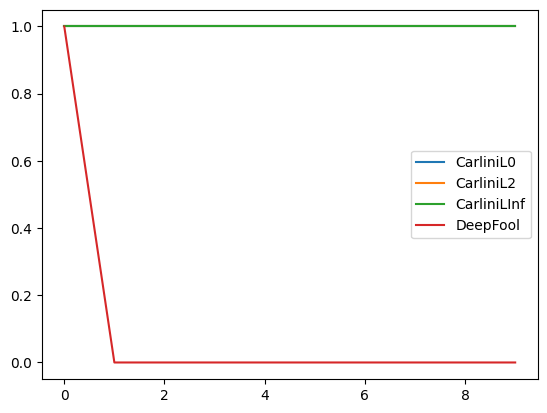

In [6]:
from matplotlib import pyplot as plt

for points_result in results.points_results:
    x_values = [x for x, y in points_result.points]
    y_values = [y for x, y in points_result.points]
    plt.plot(x_values, y_values, label=points_result.method_name)

plt.legend()
plt.show()